# Estrategias de trading con opciones

Como ya sabemos 

# Greek Black-Scholes

In [1]:
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "plotly", "seaborn", "-q"], check=True)

In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator, interp1d
from scipy.optimize import brentq

from scipy.stats import norm

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns

In [3]:
df_bs = pd.DataFrame({
    "fecha_obs": ["22-ene", "29-ene", "05-feb", "10-feb", "17-feb", "19-feb", "24-feb", "26-feb", "05-mar", "17-mar", "19-mar", "25-mar", "26-mar"],
    "fecha_venc": ["09-abr"] * 13,
    "dias_restantes": [77, 70, 63, 58, 51, 49, 44, 42, 35, 23, 21, 15, 14],
    "mes_idx": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "S": [234.34, 241.73, 222.69, 206.96, 201.15, 204.44, 208.56, 207.92, 218.94, 213.50, 209.18, 211.71, 207.54],
    "T": [0.211, 0.192, 0.173, 0.159, 0.140, 0.134, 0.121, 0.115, 0.096, 0.063, 0.058, 0.041, 0.038],
    "sigma": [0.3046, 0.2990, 0.2748, 0.3022, 0.2893, 0.2857, 0.2902, 0.2871, 0.2929, 0.2886, 0.2884, 0.2940, 0.2945],
    "r_cont": [0.0417] * 13,
})

meses_es = {
    "ene": 1,
    "feb": 2,
    "mar": 3,
    "abr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "ago": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dic": 12,
}

def parse_fecha_es(fecha_str, year=2026):
    dia, mes = fecha_str.strip().lower().split("-")
    return pd.Timestamp(year=year, month=meses_es[mes], day=int(dia))

df_bs["fecha_obs"] = df_bs["fecha_obs"].apply(parse_fecha_es)
df_bs["fecha_venc"] = df_bs["fecha_venc"].apply(parse_fecha_es)

df_bs.set_index("fecha_obs")

,fecha_venc,dias_restantes,mes_idx,S,T,sigma,r_cont
fecha_obs,,,,,,,
2026-01-22,2026-04-09,77,0,234.34,0.211,0.3046,0.0417
2026-01-29,2026-04-09,70,1,241.73,0.192,0.2990,0.0417
2026-02-05,2026-04-09,63,2,222.69,0.173,0.2748,0.0417
2026-02-10,2026-04-09,58,3,206.96,0.159,0.3022,0.0417
2026-02-17,2026-04-09,51,4,201.15,0.140,0.2893,0.0417
2026-02-19,2026-04-09,49,5,204.44,0.134,0.2857,0.0417
2026-02-24,2026-04-09,44,6,208.56,0.121,0.2902,0.0417
2026-02-26,2026-04-09,42,7,207.92,0.115,0.2871,0.0417
2026-03-05,2026-04-09,35,8,218.94,0.096,0.2929,0.0417


In [4]:
df_K = pd.DataFrame({
    "K": [140.00, 170.00, 195.00, 212.50, 227.50, 234.34, 252.50, 270.00, 280.00, 290.00, 300.00]
})

In [5]:
def bs_d1(S, K, r, sigma, T, q=0.0):
    S, K, r, sigma, T, q = map(np.asarray, (S, K, r, sigma, T, q))
    return (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def bs_d2(S, K, r, sigma, T, q=0.0):
    return bs_d1(S, K, r, sigma, T, q) - sigma * np.sqrt(T)

def bs_call_price(S, K, r, sigma, T, q=0.0):
    d1 = bs_d1(S, K, r, sigma, T, q)
    d2 = bs_d2(S, K, r, sigma, T, q)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def calc_count_int(M : float, r: float, T : float) -> float:
    return M * np.exp(r * T)


In [6]:
def call_premium_table(df_bs, df_K, q=0.0, time_col="fecha_obs"):
    base = (
        df_bs.assign(
            fecha_label=lambda x: pd.to_datetime(x[time_col]).map(
                lambda d: f"{d.year}-{d.month}-{d.day}"
            )
        )[["fecha_label", "S", "T", "sigma", "r_cont"]]
        .rename(columns={"fecha_label": "fecha"})
    )

    return (
        base.merge(df_K[["K"]], how="cross")
        .assign(
            call_price=lambda x: bs_call_price(
                S=x["S"],
                K=x["K"],
                r=x["r_cont"],
                sigma=x["sigma"],
                T=x["T"],
                q=q,
            )
        )
        .pivot(index="K", columns="fecha", values="call_price")
        .sort_index()
        .round(2)
    )


In [7]:
tabla_primas = call_premium_table(df_bs, df_K)
tabla_primas.iloc[:, 0] = [123.80, 90.87, 66.60, 42.45, 22.05, 14.50, 4.85, 1.63, 0.76, 0.70 ,0.33]
tabla_primas

fecha,2026-1-22,2026-1-29,2026-2-10,2026-2-17,2026-2-19,2026-2-24,2026-2-26,2026-2-5,2026-3-17,2026-3-19,2026-3-25,2026-3-26,2026-3-5
K,,,,,,,,,,,,,
140.00,123.80,102.85,67.89,61.97,65.22,69.26,68.59,83.70,73.87,69.52,71.95,67.76,79.50
170.00,90.87,73.11,38.51,32.59,35.65,39.55,38.85,53.97,43.95,39.60,42.00,37.81,49.63
195.00,66.60,48.80,17.66,12.66,14.61,17.36,16.61,30.36,19.70,15.72,17.48,13.62,25.53
212.50,42.45,33.18,8.11,4.74,5.66,7.10,6.48,16.82,6.96,4.54,4.82,2.84,11.97
227.50,22.05,21.87,3.53,1.64,1.99,2.58,2.22,8.71,1.78,0.90,0.76,0.31,4.81
234.34,14.50,17.56,2.30,0.94,1.15,1.51,1.25,6.14,0.82,0.36,0.26,0.08,2.91
252.50,4.85,8.95,0.64,0.18,0.22,0.29,0.22,2.10,0.07,0.02,0.01,0.00,0.59
270.00,1.63,4.12,0.16,0.03,0.04,0.05,0.03,0.61,0.00,0.00,0.00,0.00,0.09
280.00,0.76,2.51,0.07,0.01,0.01,0.01,0.01,0.28,0.00,0.00,0.00,0.00,0.03


In [8]:
tabla_primas.sum(axis = 0)

fecha
2026-1-22    368.54
2026-1-29    315.27
2026-2-10    138.91
2026-2-17    114.76
2026-2-19    124.55
2026-2-24    137.71
2026-2-26    134.26
2026-2-5     202.86
2026-3-17    147.15
2026-3-19    130.66
2026-3-25    137.28
2026-3-26    122.42
2026-3-5     175.07
dtype: float64

## With out strategies

En este ejercicio consideraremos una estretegia donde no consideran estrategias de convertura para cubrir los movimientos de la cartarea.

Por tanto considerando que tomamos una posición short sobre financial options call tenemos que a nosotro nos pagan una cantidad de

In [9]:
total_primes = tabla_primas.iloc[:, 0].sum()
total_primes

np.float64(368.53999999999996)

En primas por la venta de las opciones

Considerando lo anterior, si evaluamos cuales de las opciones terminaron in the mony al final del tiempo $T$ tenemos que

In [10]:
df_bs.iloc[-1]["S"] > df_K

,K
0,True
1,True
2,True
3,False
4,False
5,False
6,False
7,False
8,False
9,False


3 de las 10 opciones se habrian ejersido y por tanto tendriamos que comprar el activo al precio spot y venderlo al precio strike, en ste sentido

In [11]:
stock_sell = df_K[df_bs.iloc[-1]["S"] > df_K]
stock_sell = stock_sell.fillna(0)
stock_sell

,K
0,140.0
1,170.0
2,195.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0


In [12]:
# Resultado neto
total_primes_invest = calc_count_int(M = total_primes, r = df_bs.loc[0, "r_cont"], T=df_bs.loc[0, "T"])

result_tradeoff = total_primes_invest + (stock_sell.sum() - df_bs.iloc[-1]["S"] * 3)

Por tanto nuestra ganancia perdida por esta estrategia se encuentra en

In [13]:
result_tradeoff

K    254.17698
dtype: float64

# Delta Hedging

## Theory

Como ya sabemo la dinamica de un portafolio $\Pi$ esta dado por su diferencial $d\Pi$ por tanto si consideramos el modelo

$$
d\Pi = Q_1dS_t + Q_2dc(S_t, t)
$$

tenemos que con una simple apliación el lema de Itô para $c(S_t,t)$:

$$
dc(S_t,t) =
\frac{\partial c}{\partial t}dt +
\frac{\partial c}{\partial S_t}dS_t +
\frac{1}{2}\sigma^2 S_t^2 \frac{\partial^2 c}{\partial S_t^2}dt
$$

Sustituyendo en $d\Pi_t$:

$$
d\Pi_t =
Q_1\, dS_t +
Q_2\left(
\frac{\partial c}{\partial t},dt +
\frac{\partial c}{\partial S_t}\,dS_t +
\frac{1}{2}\sigma^2 S_t^2 \frac{\partial^2 c}{\partial S_t^2}\,dt
\right)
$$

Obtenemos la forma factorizada por diferenciales:

$$
d\Pi_t =
\left(
Q_1 + Q_2 \frac{\partial c}{\partial S_t}
\right)dS_t
+
Q_2\left(
\frac{\partial c}{\partial t}
+
\frac{1}{2}\sigma^2 S_t^2 \frac{\partial^2 c}{\partial S_t^2}
\right)dt
$$

La cual en este punto deja bastante claro cuales son los terminos que determinan el grado de incertidumbre incorporado en el modelo. Por tanto si $dS_t$ es la parte del modelo que incorpora el riesgo o la incetidumbre en el mismo por ser proceso estocastico deberiamos de tratar de definir cantidades de $Q_1$ y $Q_2$ de tal manera que podamos eliminar este termino estocastico.

Aquí es donde justamente se incorpora la idea del **delta hedging** la cual es tomar $Q_1$ y $Q_2$ de tal manera que el factor de incertidumbre $dS_t$ pueda ser eliminado.

El término estocástico está dado por

$$
\left(
Q_1 + Q_2 \frac{\partial c}{\partial S_t}
\right)dS_t
$$

Por lo tanto, para eliminar la incertidumbre se impone la condición de **neutralidad delta**:

$$
Q_1 + Q_2 \frac{\partial c}{\partial S_t} = 0
$$

de donde

$$
Q_1 = - Q_2 \frac{\partial c}{\partial S_t}
$$

Sustituyendo esta elección en $d\Pi_t$, el término en $dS_t$ se neutraliza (elimina) y se obtiene un portafolio delta-neutral:

$$
d\Pi_t^{(\Delta)} =
Q_2\left(
\frac{\partial c}{\partial t}
+
\frac{1}{2}\sigma^2 S_t^2 \frac{\partial^2 c}{\partial S_t^2}
\right)dt
$$

Es decir, el diferencial del portafolio ya no depende de $dS_t$, sino únicamente de $dt$, por lo que queda localmente libre de riesgo.


Por tanto nuestra estrategía donde si $Q_2 = -1$ consisten en determinar la cantidad

$$
Q_1 = \frac{\partial c}{\partial S_t}
$$

De esta forma ahora nuestro segundo problema se encuentra en determinar como podemos calcular el $\Delta$ de un portafolio de opciones

Para ello, si consideramos que el valor de un call $C(S_t, t)$ está dado por

$$
C(S_t, t) = N(d_1)S_t - Ke^{-r(T-t)}N(d_2)
$$

donde

$$
d_1 = \frac{\ln\left(\frac{S_t}{K}\right) + \left(r+\frac{1}{2}\sigma^2\right)(T-t)}{\sigma\sqrt{T-t}}
\qquad \text{y} \qquad
d_2 = d_1 - \sigma\sqrt{T-t},
$$

el cálculo de la parcial de $C(S_t, t)$ respecto de $S_t$ se obtiene aplicando la regla del producto y la regla de la cadena:

$$
\Delta_{call} = \frac{\partial C}{\partial S_t} =
\frac{\partial}{\partial S_t}\left(S_tN(d_1)\right) -
\frac{\partial}{\partial S_t}\left(Ke^{-r(T-t)}N(d_2)\right)
$$

Como $Ke^{-r(T-t)}$ es constante respecto de $S_t$, entonces

$$
\frac{\partial C}{\partial S_t} =
N(d_1) + S_t N'(d_1)\frac{\partial d_1}{\partial S_t} -
Ke^{-r(T-t)}N'(d_2)\frac{\partial d_2}{\partial S_t}
$$

donde $N'(x)=\phi(x)$, con $\phi(x)$ la densidad de la normal estándar.

Ahora, como

$$
\frac{\partial d_1}{\partial S_t} =
\frac{1}{S_t\sigma\sqrt{T-t}}
\qquad \text{y} \qquad
\frac{\partial d_2}{\partial S_t} =
\frac{1}{S_t\sigma\sqrt{T-t}},
$$

se tiene

$$
\frac{\partial C}{\partial S_t} =
N(d_1) +
S_t\phi(d_1)\frac{1}{S_t\sigma\sqrt{T-t}} -
Ke^{-r(T-t)}\phi(d_2)\frac{1}{S_t\sigma\sqrt{T-t}}
$$

es decir,

$$
\frac{\partial C}{\partial S_t} =
N(d_1) +
\frac{\phi(d_1)}{\sigma\sqrt{T-t}} -
\frac{Ke^{-r(T-t)}\phi(d_2)}{S_t\sigma\sqrt{T-t}}
$$

Utilizando la identidad

$$
S_t\phi(d_1)=Ke^{-r(T-t)}\phi(d_2),
$$

los dos últimos términos se cancelan, por lo que finalmente se obtiene

$$
\frac{\partial C}{\partial S_t}=N(d_1)
$$

Por lo tanto, la delta de un call europeo en el modelo de Black-Scholes es

$$
\Delta_{call} = \frac{\partial C}{\partial S_t}=N(d_1)
$$


## Code

In [14]:
# Calculo de la delta de un call para cada combinacion fecha-strike
def bs_call_delta(S, K, r, sigma, T, q=0.0):
    d1 = bs_d1(S, K, r, sigma, T, q)
    return np.exp(-q * T) * norm.cdf(d1)

def call_delta_table(df_bs, df_K, q=0.0, time_col="fecha_obs", include_details=False):
    # 1. Variables de entrada del modelo en cada fecha.
    base = df_bs[[time_col, "S", "T", "sigma", "r_cont"]].copy()
    base["fecha"] = pd.to_datetime(base[time_col])

    # 2. Una fila por cada combinacion de fecha y strike.
    delta_long = base.merge(df_K[["K"]], how="cross")

    # 3. Calculo explicito de d1 y de la delta del call.
    delta_long["d1"] = bs_d1(
        S=delta_long["S"],
        K=delta_long["K"],
        r=delta_long["r_cont"],
        sigma=delta_long["sigma"],
        T=delta_long["T"],
        q=q,
    )
    
    delta_long["delta_call"] = np.exp(-q * delta_long["T"]) * norm.cdf(delta_long["d1"])

    # 4. Tabla final: strikes en filas y fechas en columnas, en orden cronologico real.
    tabla_delta = (
        delta_long
        .pivot(index="K", columns="fecha", values="delta_call")
        .sort_index()
        .sort_index(axis=1)
        .round(4)
    )
    tabla_delta.columns = tabla_delta.columns.strftime("%Y-%m-%d")
    tabla_delta = tabla_delta.reset_index()

    if include_details:
        return tabla_delta, delta_long

    return tabla_delta


In [15]:
tabla_deltas = call_delta_table(df_bs, df_K)
tabla_deltas

fecha,K,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
0,140.00,0.9999,1.0000,1.0000,0.9996,0.9997,0.9999,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,170.00,0.9924,0.9975,0.9935,0.9598,0.9518,0.9692,0.9832,0.9848,0.9980,0.9994,0.9989,0.9999,0.9998
2,195.00,0.9260,0.9613,0.9001,0.7288,0.6535,0.7115,0.7783,0.7754,0.9139,0.9072,0.8600,0.9250,0.8733
3,212.50,0.7973,0.8666,0.7020,0.4586,0.3449,0.3959,0.4662,0.4499,0.6622,0.5546,0.4376,0.4984,0.3613
4,227.50,0.6348,0.7223,0.4734,0.2514,0.1517,0.1798,0.2234,0.2043,0.3695,0.2106,0.1273,0.1251,0.0614
5,234.34,0.5528,0.6419,0.3723,0.1799,0.0963,0.1152,0.1459,0.1291,0.2548,0.1125,0.0587,0.0497,0.0197
6,252.50,0.3444,0.4184,0.1638,0.0624,0.0232,0.0279,0.0364,0.0289,0.0692,0.0124,0.0041,0.0019,0.0004
7,270.00,0.1896,0.2365,0.0588,0.0183,0.0045,0.0053,0.0070,0.0049,0.0132,0.0008,0.0002,0.0000,0.0000
8,280.00,0.1273,0.1598,0.0298,0.0084,0.0016,0.0019,0.0024,0.0015,0.0044,0.0001,0.0000,0.0000,0.0000
9,290.00,0.0822,0.1033,0.0142,0.0036,0.0005,0.0006,0.0008,0.0005,0.0013,0.0000,0.0000,0.0000,0.0000


La suma total de las deltas para cada periodo corresponde al total de la exposición en el activo necesaria para convertir al portafolios en $\Delta$-neutral localmente

In [16]:
deltas = tabla_deltas.drop(columns="K").sum(axis=0)
deltas

fecha
2026-01-22    5.6980
2026-01-29    6.1716
2026-02-05    4.7143
2026-02-10    3.6723
2026-02-17    3.2279
2026-02-19    3.4074
2026-02-24    3.6438
2026-02-26    3.5794
2026-03-05    4.2869
2026-03-17    3.7976
2026-03-19    3.4868
2026-03-25    3.6000
2026-03-26    3.3159
dtype: float64

In [17]:
df_delta_strategy = pd.DataFrame(deltas).reset_index().T

df_delta_strategy.columns = df_delta_strategy.loc["fecha"]
df_delta_strategy = df_delta_strategy.drop("fecha")

df_delta_strategy.index = ["Delta"]

delta = pd.to_numeric(df_delta_strategy.loc["Delta"], errors="coerce")

df_delta_strategy.loc["Delta diff"] = delta.diff()
df_delta_strategy.loc["Delta diff", df_delta_strategy.columns[0]] = delta.iloc[0]

df_delta_strategy.loc["Delta * St"] = (
    pd.to_numeric(df_delta_strategy.loc["Delta diff"], errors="coerce").values
    * df_bs.loc[:, "S"].to_numpy()
)

df_delta_strategy.loc["Total gains loss"] = pd.to_numeric(
    df_delta_strategy.loc["Delta * St"], errors="coerce"
).cumsum()

df_delta_strategy


fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
Delta,5.698,6.1716,4.7143,3.6723,3.2279,3.4074,3.6438,3.5794,4.2869,3.7976,3.4868,3.6,3.3159
Delta diff,5.698,0.4736,-1.4573,-1.042,-0.4444,0.1795,0.2364,-0.0644,0.7075,-0.4893,-0.3108,0.1132,-0.2841
Delta * St,1335.26932,114.483328,-324.526137,-215.65232,-89.39106,36.69698,49.303584,-13.390048,154.90005,-104.46555,-65.013144,23.965572,-58.962114
Total gains loss,1335.26932,1449.752648,1125.226511,909.574191,820.183131,856.880111,906.183695,892.793647,1047.693697,943.228147,878.215003,902.180575,843.218461


In [18]:
total_primes_invest = calc_count_int(M = total_primes, r = df_bs.loc[0, "r_cont"], T=df_bs.loc[0, "T"])

buy_stocks = df_delta_strategy.iloc[-1,-1]

sell_stocks = stock_sell.sum()

scenario2 = total_primes  + sell_stocks - buy_stocks 
scenario2

K    30.321539
dtype: float64

In [19]:
scenario2 / total_primes

K    0.082275
dtype: float64

# Delta-Gamma Hedging

## Theory

## Code

In [20]:
def bs_call_gamma(S, K, r, sigma, T, q=0.0):
    d1 = bs_d1(S, K, r, sigma, T, q)
    return np.exp(-q * T) * norm.pdf(d1) / (S * sigma * np.sqrt(T))


def lambda_delta_adjustment(S, sigma, T):
    return np.sqrt(0.5 * T) * S * sigma**2


def _pivot_metric_table(df, value_col):
    table = (
        df.pivot(index="K", columns="fecha", values=value_col)
        .sort_index()
        .sort_index(axis=1)
        .round(4)
    )
    table.columns = table.columns.strftime("%Y-%m-%d")
    return table.reset_index()


def build_adjusted_delta_tables(df_bs, df_K, q=0.0, time_col="fecha_obs", include_details=False):
    base = df_bs[[time_col, "S", "T", "sigma", "r_cont"]].copy()
    base["fecha"] = pd.to_datetime(base[time_col])

    greeks = base.merge(df_K[["K"]], how="cross")
    greeks["d1"] = bs_d1(
        S=greeks["S"],
        K=greeks["K"],
        r=greeks["r_cont"],
        sigma=greeks["sigma"],
        T=greeks["T"],
        q=q,
    )

    greeks["delta_call"] = bs_call_delta(
        S=greeks["S"],
        K=greeks["K"],
        r=greeks["r_cont"],
        sigma=greeks["sigma"],
        T=greeks["T"],
        q=q,
    )
    greeks["gamma_call"] = bs_call_gamma(
        S=greeks["S"],
        K=greeks["K"],
        r=greeks["r_cont"],
        sigma=greeks["sigma"],
        T=greeks["T"],
        q=q,
    )
    greeks["lambda_ajuste"] = lambda_delta_adjustment(
        S=greeks["S"],
        sigma=greeks["sigma"],
        T=greeks["T"],
    )
    greeks["delta_ajustada"] = greeks["delta_call"] - greeks["lambda_ajuste"] * greeks["gamma_call"]

    tables = {
        "delta": _pivot_metric_table(greeks, "delta_call"),
        "gamma": _pivot_metric_table(greeks, "gamma_call"),
        "lambda": _pivot_metric_table(greeks, "lambda_ajuste"),
        "delta_ajustada": _pivot_metric_table(greeks, "delta_ajustada"),
    }

    if include_details:
        return tables, greeks

    return tables


def build_hedging_strategy(exposure_by_date, spot_series, exposure_label):
    strategy = pd.DataFrame(exposure_by_date).reset_index().T
    strategy.columns = strategy.loc["fecha"]
    strategy = strategy.drop("fecha")
    strategy.index = [exposure_label]

    exposure = pd.to_numeric(strategy.loc[exposure_label], errors="coerce")
    diff_label = f"{exposure_label} diff"

    strategy.loc[diff_label] = exposure.diff()
    strategy.loc[diff_label, strategy.columns[0]] = exposure.iloc[0]
    strategy.loc["Rebalanceo * St"] = pd.to_numeric(
        strategy.loc[diff_label], errors="coerce"
    ).to_numpy() * np.asarray(spot_series)
    strategy.loc["Total gains loss"] = pd.to_numeric(
        strategy.loc["Rebalanceo * St"], errors="coerce"
    ).cumsum()

    return strategy


tablas_ajuste, detalle_ajuste = build_adjusted_delta_tables(
    df_bs,
    df_K,
    include_details=True,
)

tabla_delta_ajustada = tablas_ajuste["delta_ajustada"]
delta_ajustada_total = tabla_delta_ajustada.drop(columns="K").sum(axis=0)

df_delta_gamma_strategy = build_hedging_strategy(
    exposure_by_date=delta_ajustada_total,
    spot_series=df_bs["S"],
    exposure_label="Delta ajustada",
)

tabla_delta_ajustada

fecha,K,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
0,140.00,0.9999,1.0000,1.0000,0.9993,0.9995,0.9998,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,170.00,0.9879,0.9959,0.9899,0.9412,0.9313,0.9552,0.9747,0.9771,0.9967,0.9989,0.9981,0.9998,0.9996
2,195.00,0.8958,0.9436,0.8660,0.6580,0.5781,0.6425,0.7173,0.7146,0.8814,0.8733,0.8146,0.8956,0.8300
3,212.50,0.7365,0.8210,0.6346,0.3738,0.2696,0.3181,0.3846,0.3696,0.5865,0.4740,0.3572,0.4154,0.2833
4,227.50,0.5538,0.6514,0.3961,0.1833,0.1036,0.1268,0.1621,0.1467,0.2914,0.1517,0.0848,0.0823,0.0361
5,234.34,0.4677,0.5630,0.2988,0.1238,0.0614,0.0759,0.0990,0.0864,0.1883,0.0735,0.0348,0.0284,0.0098
6,252.50,0.2651,0.3358,0.1158,0.0361,0.0120,0.0149,0.0201,0.0155,0.0416,0.0059,0.0016,0.0006,0.0001
7,270.00,0.1312,0.1713,0.0360,0.0087,0.0018,0.0022,0.0030,0.0020,0.0062,0.0002,0.0000,0.0000,0.0000
8,280.00,0.0824,0.1084,0.0167,0.0035,0.0005,0.0007,0.0009,0.0005,0.0017,0.0000,0.0000,-0.0000,-0.0000
9,290.00,0.0495,0.0653,0.0072,0.0013,0.0001,0.0002,0.0002,0.0001,0.0004,0.0000,0.0000,-0.0000,-0.0000


In [21]:
df_delta_gamma_strategy

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
Delta ajustada,5.1984,5.6932,4.364,3.3295,2.9579,3.1363,3.362,3.3125,3.9943,3.5775,3.2911,3.4221,3.1589
Delta ajustada diff,5.1984,0.4948,-1.3292,-1.0345,-0.3716,0.1784,0.2257,-0.0495,0.6818,-0.4168,-0.2864,0.131,-0.2632
Rebalanceo * St,1218.193056,119.608004,-295.999548,-214.10012,-74.74734,36.472096,47.071992,-10.29204,149.273292,-88.9868,-59.909152,27.73401,-54.624528
Total gains loss,1218.193056,1337.80106,1041.801512,827.701392,752.954052,789.426148,836.49814,826.2061,975.479392,886.492592,826.58344,854.31745,799.692922


In [22]:
total_primes_invest

buy_stocks = df_delta_gamma_strategy.iloc[-1,-1]

sell_stocks = stock_sell.sum()

scenario3 = total_primes  + sell_stocks - buy_stocks 
scenario3

K    73.847078
dtype: float64

# Greek Black-Scholes with implied volatility

## Theory

## Code

In [24]:
def normalize_option_type(option_type):
    option_type = str(option_type).strip().lower()
    if option_type in {"c", "call"}:
        return "call"
    if option_type in {"p", "put"}:
        return "put"
    raise ValueError("option_type debe ser 'call' o 'put'.")


def bs_option_price(S, K, r, sigma, T, option_type="call", q=0.0):
    option_type = normalize_option_type(option_type)
    S, K, r, sigma, T, q = map(np.asarray, (S, K, r, sigma, T, q))

    intrinsic = np.where(
        option_type == "call",
        np.maximum(S - K, 0.0),
        np.maximum(K - S, 0.0),
    )

    valid_time = T > 0
    price = intrinsic.astype(float) if isinstance(intrinsic, np.ndarray) else float(intrinsic)

    if np.any(valid_time):
        d1 = bs_d1(S, K, r, sigma, T, q)
        d2 = bs_d2(S, K, r, sigma, T, q)
        call_price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
        full_price = np.where(option_type == "call", call_price, put_price)
        price = np.where(valid_time, full_price, intrinsic)

    return price


def option_price_bounds(S, K, r, T, option_type="call", q=0.0):
    option_type = normalize_option_type(option_type)
    discounted_spot = S * np.exp(-q * T)
    discounted_strike = K * np.exp(-r * T)

    if option_type == "call":
        lower = max(discounted_spot - discounted_strike, 0.0)
        upper = discounted_spot
    else:
        lower = max(discounted_strike - discounted_spot, 0.0)
        upper = discounted_strike

    return lower, upper


def implied_volatility(
    market_price,
    S,
    K,
    r,
    T,
    option_type="call",
    q=0.0,
    sigma_min=1e-6,
    sigma_max=3.0,
    price_tol=1e-8,
    max_sigma_expansions=8,
):
    option_type = normalize_option_type(option_type)

    if pd.isna(market_price) or pd.isna(S) or pd.isna(K) or pd.isna(r) or pd.isna(T):
        return np.nan
    if market_price <= 0 or S <= 0 or K <= 0 or T <= 0:
        return np.nan

    lower_bound, upper_bound = option_price_bounds(S, K, r, T, option_type=option_type, q=q)
    if market_price < lower_bound - price_tol or market_price > upper_bound + price_tol:
        return np.nan
    if np.isclose(market_price, lower_bound, atol=price_tol):
        return sigma_min

    def objective(sigma):
        return bs_option_price(S, K, r, sigma, T, option_type=option_type, q=q) - market_price

    sigma_upper = sigma_max
    f_low = objective(sigma_min)
    f_high = objective(sigma_upper)

    expansions = 0
    while f_high < 0 and expansions < max_sigma_expansions:
        sigma_upper *= 2
        f_high = objective(sigma_upper)
        expansions += 1

    if f_low * f_high > 0:
        return np.nan

    return brentq(objective, sigma_min, sigma_upper)


def add_surface_coordinates(df_quotes, spot_col="S", strike_col="K", maturity_col="T", rate_col="r_cont", dividend_col=None):
    quotes = df_quotes.copy()
    dividend = 0.0 if dividend_col is None else quotes[dividend_col]

    quotes["forward"] = quotes[spot_col] * np.exp((quotes[rate_col] - dividend) * quotes[maturity_col])
    quotes["moneyness"] = quotes[spot_col] / quotes[strike_col]
    quotes["log_moneyness"] = np.log(quotes[spot_col] / quotes[strike_col])
    quotes["forward_moneyness"] = quotes[strike_col] / quotes["forward"]
    quotes["log_forward_moneyness"] = np.log(quotes["forward_moneyness"])

    return quotes


def compute_implied_vols(
    df_quotes,
    price_col="market_price",
    spot_col="S",
    strike_col="K",
    rate_col="r_cont",
    maturity_col="T",
    option_type_col="option_type",
    dividend_col=None,
):
    quotes = add_surface_coordinates(
        df_quotes,
        spot_col=spot_col,
        strike_col=strike_col,
        maturity_col=maturity_col,
        rate_col=rate_col,
        dividend_col=dividend_col,
    )

    quotes["q"] = 0.0 if dividend_col is None else quotes[dividend_col]
    quotes["iv"] = quotes.apply(
        lambda row: implied_volatility(
            market_price=row[price_col],
            S=row[spot_col],
            K=row[strike_col],
            r=row[rate_col],
            T=row[maturity_col],
            option_type=row[option_type_col],
            q=row["q"],
        ),
        axis=1,
    )

    return quotes.drop(columns="q")


def build_vol_surface_table(df_iv, x_col="log_forward_moneyness", y_col="T", iv_col="iv", decimals=4):
    table = (
        df_iv.pivot_table(index=x_col, columns=y_col, values=iv_col, aggfunc="mean")
        .sort_index()
        .sort_index(axis=1)
        .round(decimals)
    )
    return table.reset_index()


def fit_vol_smile_interpolator(df_iv, x_col="log_forward_moneyness", iv_col="iv", maturity_col="T"):
    smile_data = (
        df_iv[[x_col, maturity_col, iv_col]]
        .dropna()
        .groupby([x_col, maturity_col], as_index=False)[iv_col]
        .mean()
        .sort_values(x_col)
    )

    if smile_data[maturity_col].nunique() != 1:
        raise ValueError("El smile requiere un unico vencimiento.")
    if smile_data[x_col].nunique() < 2:
        raise ValueError("Se requieren al menos dos strikes para interpolar un smile.")

    maturity = float(smile_data[maturity_col].iloc[0])
    interpolator = interp1d(
        smile_data[x_col],
        smile_data[iv_col],
        kind="linear",
        bounds_error=False,
        fill_value=(smile_data[iv_col].iloc[0], smile_data[iv_col].iloc[-1]),
    )

    def smile_fn(x, T=None):
        if T is not None and not np.isclose(np.asarray(T, dtype=float), maturity).all():
            raise ValueError("Este interpolador solo es valido para el vencimiento usado al ajustar el smile.")
        return np.asarray(interpolator(x), dtype=float)

    return smile_fn


def fit_vol_surface_interpolator(df_iv, x_col="log_forward_moneyness", y_col="T", iv_col="iv"):
    surface_data = (
        df_iv[[x_col, y_col, iv_col]]
        .dropna()
        .groupby([x_col, y_col], as_index=False)[iv_col]
        .mean()
    )

    if surface_data[x_col].nunique() < 2 or surface_data[y_col].nunique() < 2 or len(surface_data) < 3:
        raise ValueError("La superficie requiere varios strikes y varios vencimientos en la misma fecha.")

    points = surface_data[[x_col, y_col]].to_numpy(dtype=float)
    values = surface_data[iv_col].to_numpy(dtype=float)

    linear = LinearNDInterpolator(points, values, fill_value=np.nan)
    nearest = NearestNDInterpolator(points, values)

    def surface_fn(x, T):
        linear_value = np.asarray(linear(x, T), dtype=float)
        nearest_value = np.asarray(nearest(x, T), dtype=float)
        return np.where(np.isnan(linear_value), nearest_value, linear_value)

    return surface_fn


def prepare_vol_model(
    df_quotes,
    valuation_date=None,
    date_col="fecha_obs",
    x_col="log_forward_moneyness",
    y_col="T",
    iv_col="iv",
):
    quotes = df_quotes.copy()

    if date_col in quotes.columns:
        quotes[date_col] = pd.to_datetime(quotes[date_col])
        if valuation_date is not None:
            valuation_date = pd.to_datetime(valuation_date)
            quotes = quotes.loc[quotes[date_col] == valuation_date].copy()
        elif quotes[date_col].nunique() > 1:
            raise ValueError("Una superficie de volatilidad se construye para una sola fecha de valuacion.")

    quotes_iv = compute_implied_vols(quotes)
    quotes_iv = quotes_iv.dropna(subset=[iv_col, x_col, y_col]).copy()
    vol_table = build_vol_surface_table(quotes_iv, x_col=x_col, y_col=y_col, iv_col=iv_col)

    if quotes_iv[y_col].nunique() == 1:
        model_type = "smile"
        vol_fn = fit_vol_smile_interpolator(quotes_iv, x_col=x_col, iv_col=iv_col, maturity_col=y_col)
    else:
        model_type = "surface"
        vol_fn = fit_vol_surface_interpolator(quotes_iv, x_col=x_col, y_col=y_col, iv_col=iv_col)

    return {
        "model_type": model_type,
        "quotes_iv": quotes_iv,
        "vol_table": vol_table,
        "vol_fn": vol_fn,
        "x_col": x_col,
        "y_col": y_col,
        "iv_col": iv_col,
    }


def evaluate_vol_model(vol_model, S, K, T, r, q=0.0):
    if vol_model["x_col"] == "log_forward_moneyness":
        forward = S * np.exp((r - q) * T)
        x_value = np.log(K / forward)
    elif vol_model["x_col"] == "log_moneyness":
        x_value = np.log(S / K)
    else:
        raise ValueError("El evaluador solo soporta log_forward_moneyness y log_moneyness.")

    vol_value = vol_model["vol_fn"](x_value, T)
    return float(np.asarray(vol_value).reshape(-1)[0])


def build_quotes_from_price_table(price_table, df_bs, option_type="call", price_col="market_price", time_col="fecha_obs"):
    quotes = (
        price_table.reset_index()
        .melt(id_vars="K", var_name=time_col, value_name=price_col)
        .assign(
            option_type=normalize_option_type(option_type),
            fecha_obs=lambda x: pd.to_datetime(x[time_col]),
        )
        .merge(df_bs[[time_col, "S", "T", "r_cont"]], on=time_col, how="left")
    )

    return quotes[[time_col, "option_type", price_col, "S", "K", "T", "r_cont"]]


def load_surface_quotes_csv(
    csv_path,
    valuation_date=None,
    rate=0.0417,
    dividend_yield=0.0,
    use_otm_only=True,
):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        alt_path = Path("src/proyect") / csv_path.name
        if alt_path.exists():
            csv_path = alt_path
        else:
            raise FileNotFoundError(f"No se encontro el archivo: {csv_path}")

    quotes = pd.read_csv(csv_path)
    quotes = quotes.drop(columns=["Unnamed: 0"], errors="ignore")

    if "date" in quotes.columns:
        quotes["date"] = pd.to_datetime(quotes["date"])
    if "expiration_date" in quotes.columns:
        quotes["expiration_date"] = pd.to_datetime(quotes["expiration_date"])
    if "option_type" in quotes.columns:
        quotes["option_type"] = quotes["option_type"].map(normalize_option_type)

    if valuation_date is not None and "date" in quotes.columns:
        valuation_date = pd.to_datetime(valuation_date)
        quotes = quotes.loc[quotes["date"] == valuation_date].copy()

    if "mid" not in quotes.columns and {"bid", "ask"}.issubset(quotes.columns):
        bid = pd.to_numeric(quotes["bid"], errors="coerce")
        ask = pd.to_numeric(quotes["ask"], errors="coerce")
        quotes["mid"] = (bid + ask) / 2

    if "market_price" in quotes.columns:
        quotes["market_price"] = pd.to_numeric(quotes["market_price"], errors="coerce")
    elif "mid" in quotes.columns:
        quotes["market_price"] = pd.to_numeric(quotes["mid"], errors="coerce")
    else:
        raise ValueError("No se encontro una columna de precio de mercado ni una columna 'mid'.")

    spot_source = "S" if "S" in quotes.columns else "underlying_price"
    strike_source = "K" if "K" in quotes.columns else "strike"
    quotes["S"] = pd.to_numeric(quotes[spot_source], errors="coerce")
    quotes["K"] = pd.to_numeric(quotes[strike_source], errors="coerce")

    if "T" in quotes.columns:
        quotes["T"] = pd.to_numeric(quotes["T"], errors="coerce")
    elif {"date", "expiration_date"}.issubset(quotes.columns):
        quotes["T"] = (quotes["expiration_date"] - quotes["date"]).dt.days / 365.0
    else:
        raise ValueError("No fue posible construir T. Se requiere 'T' o las columnas 'date' y 'expiration_date'.")

    if "r_cont" in quotes.columns:
        quotes["r_cont"] = pd.to_numeric(quotes["r_cont"], errors="coerce").fillna(float(rate))
    else:
        quotes["r_cont"] = float(rate)

    if "q" in quotes.columns:
        quotes["q"] = pd.to_numeric(quotes["q"], errors="coerce").fillna(float(dividend_yield))
    else:
        quotes["q"] = float(dividend_yield)

    valid_quotes = (
        (quotes["market_price"] > 0)
        & (quotes["S"] > 0)
        & (quotes["K"] > 0)
        & (quotes["T"] > 0)
    )

    if {"bid", "ask"}.issubset(quotes.columns):
        bid = pd.to_numeric(quotes["bid"], errors="coerce")
        ask = pd.to_numeric(quotes["ask"], errors="coerce")
        valid_quotes &= (bid > 0) & (ask > 0) & (ask >= bid)

    quotes = quotes.loc[valid_quotes].copy()
    quotes["is_otm"] = True

    if use_otm_only and "option_type" in quotes.columns:
        quotes["is_otm"] = (
            ((quotes["option_type"] == "call") & (quotes["K"] >= quotes["S"]))
            | ((quotes["option_type"] == "put") & (quotes["K"] <= quotes["S"]))
        )
        quotes = quotes.loc[quotes["is_otm"]].copy()

    return quotes.reset_index(drop=True)


def summarize_exercise_strikes(df_quotes, exercise_strikes):
    rows = []

    for strike in exercise_strikes:
        strike_quotes = df_quotes.loc[np.isclose(df_quotes["K"], float(strike))].copy()
        min_expiration = pd.NA
        max_expiration = pd.NA

        if not strike_quotes.empty and "expiration_date" in strike_quotes.columns:
            min_expiration = strike_quotes["expiration_date"].min().strftime("%Y-%m-%d")
            max_expiration = strike_quotes["expiration_date"].max().strftime("%Y-%m-%d")

        rows.append(
            {
                "strike": float(strike),
                "observed_in_surface": not strike_quotes.empty,
                "surface_action": "observed" if not strike_quotes.empty else "interpolate",
                "option_types": ", ".join(sorted(strike_quotes["option_type"].unique().tolist())) if not strike_quotes.empty else "",
                "num_quotes": int(len(strike_quotes)),
                "min_expiration": min_expiration,
                "max_expiration": max_expiration,
            }
        )

    return pd.DataFrame(rows)


def format_sigma_row_label(strike):
    strike_label = f"{float(strike):.2f}".rstrip("0").rstrip(".")
    return f"sigma implied {strike_label}"


def classify_surface_evaluation(vol_model, S, K, T, r, q=0.0, maturity_tol_days=1.0):
    quotes_iv = vol_model["quotes_iv"]
    maturity_tol = maturity_tol_days / 365.0

    exact_point = np.isclose(quotes_iv["K"], float(K)) & np.isclose(quotes_iv["T"], float(T), atol=maturity_tol)
    if exact_point.any():
        return "observada"

    same_strike = np.isclose(quotes_iv["K"], float(K))
    if same_strike.any():
        strike_maturities = quotes_iv.loc[same_strike, "T"]
        if strike_maturities.min() - maturity_tol <= float(T) <= strike_maturities.max() + maturity_tol:
            return "interpolada_T"
        return "extrapolada_T"

    target_x = np.log(K / (S * np.exp((r - q) * T)))
    x_min = float(quotes_iv[vol_model["x_col"]].min())
    x_max = float(quotes_iv[vol_model["x_col"]].max())
    t_min = float(quotes_iv["T"].min())
    t_max = float(quotes_iv["T"].max())

    if x_min <= target_x <= x_max and t_min - maturity_tol <= float(T) <= t_max + maturity_tol:
        return "interpolada_superficie"

    return "extrapolada_superficie"


def build_surface_sigma_tables(
    df_bs,
    df_K,
    quotes_csv_path="AMZN_options_base_3m.csv",
    q=0.0,
    rate=0.0417,
    use_otm_only=True,
    time_col="fecha_obs",
):
    market_quotes = load_surface_quotes_csv(
        quotes_csv_path,
        valuation_date=None,
        rate=rate,
        dividend_yield=q,
        use_otm_only=use_otm_only,
    )

    ordered_dates = pd.to_datetime(df_bs[time_col]).tolist()
    records = []
    daily_models = {}

    for _, obs in df_bs[[time_col, "S", "T", "r_cont"]].iterrows():
        valuation_date = pd.to_datetime(obs[time_col])
        daily_quotes = market_quotes.loc[market_quotes["date"] == valuation_date].copy()

        if daily_quotes.empty:
            raise ValueError(f"No hay cotizaciones suficientes para construir la superficie en {valuation_date:%Y-%m-%d}.")

        daily_model = prepare_vol_model(
            daily_quotes,
            valuation_date=valuation_date,
            date_col="date",
        )
        daily_models[valuation_date] = daily_model

        for strike in pd.to_numeric(df_K["K"], errors="coerce"):
            sigma_value = evaluate_vol_model(
                daily_model,
                S=float(obs["S"]),
                K=float(strike),
                T=float(obs["T"]),
                r=float(obs["r_cont"]),
                q=q,
            )
            source_type = classify_surface_evaluation(
                daily_model,
                S=float(obs["S"]),
                K=float(strike),
                T=float(obs["T"]),
                r=float(obs["r_cont"]),
                q=q,
            )

            records.append(
                {
                    "fecha": valuation_date,
                    "K": float(strike),
                    "sigma": float(sigma_value),
                    "fuente_sigma": source_type,
                    "S_objetivo": float(obs["S"]),
                    "T_objetivo": float(obs["T"]),
                    "r_objetivo": float(obs["r_cont"]),
                }
            )

    sigma_long = pd.DataFrame(records)
    strike_order = pd.to_numeric(df_K["K"], errors="coerce").tolist()

    sigma_table = (
        sigma_long.pivot(index="K", columns="fecha", values="sigma")
        .reindex(index=strike_order, columns=ordered_dates)
        .round(4)
    )
    sigma_source_table = (
        sigma_long.pivot(index="K", columns="fecha", values="fuente_sigma")
        .reindex(index=strike_order, columns=ordered_dates)
    )

    sigma_table.index = [format_sigma_row_label(strike) for strike in sigma_table.index]
    sigma_source_table.index = [format_sigma_row_label(strike) for strike in sigma_source_table.index]
    sigma_table.columns = [date.strftime("%Y-%m-%d") for date in ordered_dates]
    sigma_source_table.columns = [date.strftime("%Y-%m-%d") for date in ordered_dates]

    sigma_table_pct = sigma_table.apply(lambda column: column.map(lambda value: f"{value:.2%}" if pd.notna(value) else ""))

    return {
        "sigma_table": sigma_table,
        "sigma_table_pct": sigma_table_pct,
        "sigma_source_table": sigma_source_table,
        "sigma_details": sigma_long,
        "daily_models": daily_models,
    }


amzn_surface_valuation_date = pd.Timestamp("2026-01-29")
exercise_strikes = [140.0, 170.0, 195.0, 212.5, 227.5, 234.34, 252.5, 270.0, 280.0, 290.0, 300.0]

amzn_surface_quotes = load_surface_quotes_csv(
    "AMZN_options_base_3m.csv",
    valuation_date=amzn_surface_valuation_date,
    rate=0.0417,
    dividend_yield=0.0,
    use_otm_only=True,
)

surface_build_summary = pd.DataFrame(
    [
        {
            "valuation_date": amzn_surface_valuation_date.strftime("%Y-%m-%d"),
            "spot": round(float(amzn_surface_quotes["S"].iloc[0]), 2),
            "surface_nodes": int(len(amzn_surface_quotes)),
            "unique_expirations": int(amzn_surface_quotes["expiration_date"].nunique()),
            "unique_strikes": int(amzn_surface_quotes["K"].nunique()),
        }
    ]
)

exercise_strike_summary = summarize_exercise_strikes(amzn_surface_quotes, exercise_strikes)

amzn_surface_model = prepare_vol_model(
    amzn_surface_quotes,
    valuation_date=amzn_surface_valuation_date,
    date_col="date",
)

exercise_strike_summary

,strike,observed_in_surface,surface_action,option_types,num_quotes,min_expiration,max_expiration
0,140.00,True,observed,put,1,2026-05-15,2026-05-15
1,170.00,True,observed,put,9,2026-02-06,2026-05-15
2,195.00,True,observed,put,10,2026-02-06,2026-05-15
3,212.50,True,observed,put,4,2026-01-30,2026-02-11
4,227.50,True,observed,put,8,2026-01-30,2026-02-20
5,234.34,False,interpolate,,0,NaN,NaN
6,252.50,True,observed,call,8,2026-01-30,2026-02-20
7,270.00,True,observed,call,12,2026-02-04,2026-05-15
8,280.00,True,observed,call,11,2026-02-06,2026-05-15
9,290.00,True,observed,call,11,2026-02-06,2026-05-15


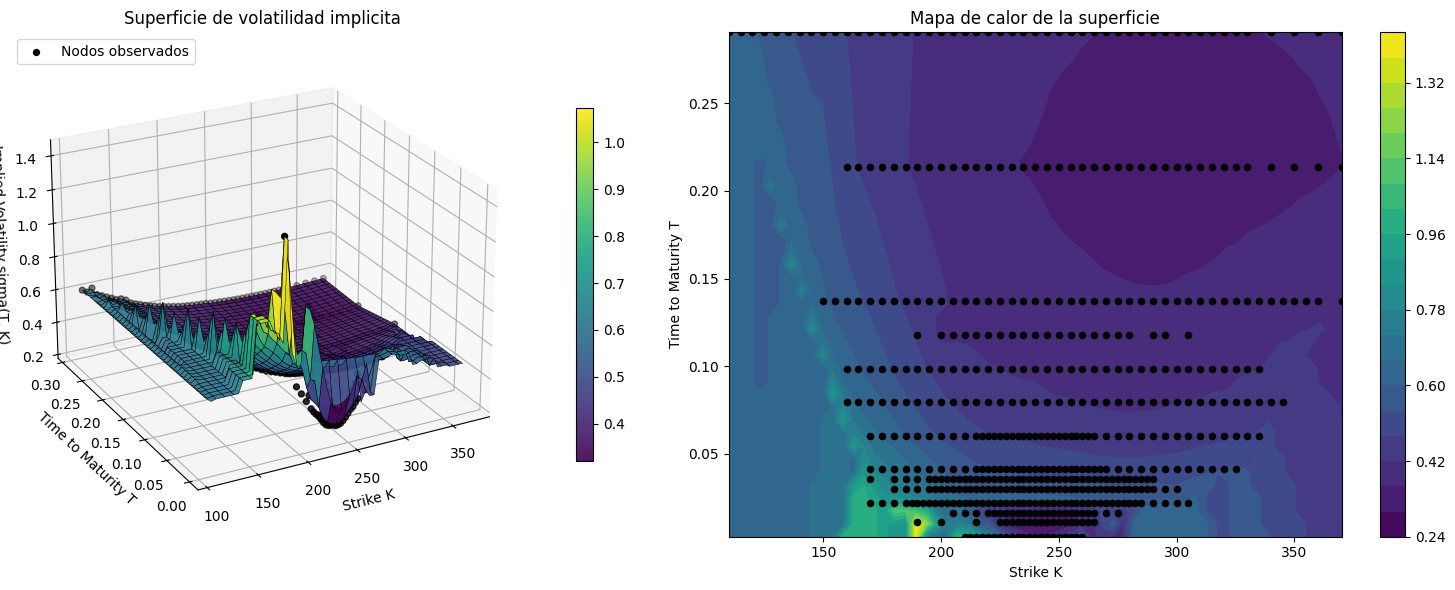

In [25]:
def to_plotly_colorscale(cmap):
    colorscale_map = {
        "viridis": "Viridis",
        "plasma": "Plasma",
        "inferno": "Inferno",
        "magma": "Magma",
        "cividis": "Cividis",
    }
    return colorscale_map.get(str(cmap).lower(), cmap)


def build_strike_surface_plot_grid(
    vol_model,
    strike_min=None,
    strike_max=None,
    maturity_min=None,
    maturity_max=None,
    num_strikes=60,
    num_maturities=40,
    q=0.0,
):
    quotes_iv = vol_model["quotes_iv"].copy()
    S_ref = float(quotes_iv["S"].iloc[0])
    r_ref = float(quotes_iv["r_cont"].iloc[0])
    q_ref = float(quotes_iv["q"].iloc[0]) if "q" in quotes_iv.columns else float(q)

    strike_min = float(quotes_iv["K"].min()) if strike_min is None else float(strike_min)
    strike_max = float(quotes_iv["K"].max()) if strike_max is None else float(strike_max)
    maturity_min = float(quotes_iv["T"].min()) if maturity_min is None else float(maturity_min)
    maturity_max = float(quotes_iv["T"].max()) if maturity_max is None else float(maturity_max)

    strike_grid = np.linspace(strike_min, strike_max, num_strikes)

    if vol_model["model_type"] == "smile":
        maturity = float(quotes_iv["T"].iloc[0])
        iv_curve = np.array([
            evaluate_vol_model(vol_model, S_ref, strike, maturity, r_ref, q=q_ref)
            for strike in strike_grid
        ])
        return {
            "model_type": "smile",
            "strike_grid": strike_grid,
            "maturity": maturity,
            "iv_curve": iv_curve,
            "quotes_iv": quotes_iv,
        }

    maturity_grid = np.linspace(maturity_min, maturity_max, num_maturities)
    strike_mesh, maturity_mesh = np.meshgrid(strike_grid, maturity_grid)
    evaluator = np.vectorize(
        lambda strike, maturity: evaluate_vol_model(vol_model, S_ref, strike, maturity, r_ref, q=q_ref),
        otypes=[float],
    )
    iv_mesh = evaluator(strike_mesh, maturity_mesh)

    return {
        "model_type": "surface",
        "strike_grid": strike_grid,
        "maturity_grid": maturity_grid,
        "strike_mesh": strike_mesh,
        "maturity_mesh": maturity_mesh,
        "iv_mesh": iv_mesh,
        "quotes_iv": quotes_iv,
    }


def plot_vol_model(vol_model, num_strikes=60, num_maturities=40, cmap="viridis", q=0.0):
    plot_data = build_strike_surface_plot_grid(
        vol_model,
        num_strikes=num_strikes,
        num_maturities=num_maturities,
        q=q,
    )

    quotes_iv = plot_data["quotes_iv"]

    if plot_data["model_type"] == "smile":
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(
            plot_data["strike_grid"],
            plot_data["iv_curve"],
            color="steelblue",
            linewidth=2,
            label="Smile interpolado",
        )
        ax.scatter(
            quotes_iv["K"],
            quotes_iv["iv"],
            color="black",
            s=35,
            label="IV observada",
            zorder=3,
        )
        ax.set_title("Smile de volatilidad implicita")
        ax.set_xlabel("Strike K")
        ax.set_ylabel("Volatilidad implicita")
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        return fig, ax

    fig = plt.figure(figsize=(16, 6))
    ax_surface = fig.add_subplot(1, 2, 1, projection="3d")
    surface = ax_surface.plot_surface(
        plot_data["strike_mesh"],
        plot_data["maturity_mesh"],
        plot_data["iv_mesh"],
        cmap=cmap,
        linewidth=0.35,
        edgecolor="black",
        antialiased=True,
        alpha=0.92,
    )
    ax_surface.scatter(
        quotes_iv["K"],
        quotes_iv["T"],
        quotes_iv["iv"],
        color="black",
        s=18,
        label="Nodos observados",
    )
    ax_surface.set_title("Superficie de volatilidad implicita")
    ax_surface.set_xlabel("Strike K")
    ax_surface.set_ylabel("Time to Maturity T")
    ax_surface.set_zlabel("Implied Volatility sigma(T, K)")
    ax_surface.view_init(elev=24, azim=-118)
    ax_surface.legend(loc="upper left")
    fig.colorbar(surface, ax=ax_surface, shrink=0.7, pad=0.08)

    ax_heatmap = fig.add_subplot(1, 2, 2)
    contour = ax_heatmap.contourf(
        plot_data["strike_mesh"],
        plot_data["maturity_mesh"],
        plot_data["iv_mesh"],
        levels=20,
        cmap=cmap,
    )
    ax_heatmap.scatter(quotes_iv["K"], quotes_iv["T"], color="black", s=20)
    ax_heatmap.set_title("Mapa de calor de la superficie")
    ax_heatmap.set_xlabel("Strike K")
    ax_heatmap.set_ylabel("Time to Maturity T")
    fig.colorbar(contour, ax=ax_heatmap)

    plt.tight_layout()
    return fig, (ax_surface, ax_heatmap)


def build_interactive_surface_figure(
    vol_model,
    num_strikes=60,
    num_maturities=40,
    cmap="viridis",
    q=0.0,
):
    plot_data = build_strike_surface_plot_grid(
        vol_model,
        num_strikes=num_strikes,
        num_maturities=num_maturities,
        q=q,
    )

    if plot_data["model_type"] != "surface":
        raise ValueError("La grafica interactiva solo esta disponible para una superficie con varios vencimientos.")

    quotes_iv = plot_data["quotes_iv"]
    colorscale = to_plotly_colorscale(cmap)
    fig = go.Figure()
    fig.add_trace(
        go.Surface(
            x=plot_data["strike_mesh"],
            y=plot_data["maturity_mesh"],
            z=plot_data["iv_mesh"],
            colorscale=colorscale,
            opacity=0.92,
            colorbar=dict(title="IV"),
            name="Superficie",
        )
    )
    fig.add_trace(
        go.Scatter3d(
            x=quotes_iv["K"],
            y=quotes_iv["T"],
            z=quotes_iv["iv"],
            mode="markers",
            marker=dict(size=3, color="black"),
            name="Nodos observados",
        )
    )
    fig.update_layout(
        title="Superficie de volatilidad implicita",
        scene=dict(
            xaxis_title="Strike K",
            yaxis_title="Time to Maturity T",
            zaxis_title="Implied Volatility sigma(T, K)",
            camera=dict(eye=dict(x=1.6, y=-1.7, z=1.0)),
        ),
        width=950,
        height=700,
        margin=dict(l=0, r=0, b=0, t=50),
    )
    return fig


if "amzn_surface_model" in globals():
    fig_amzn_surface, axes_amzn_surface = plot_vol_model(amzn_surface_model)

In [26]:
if "amzn_surface_model" in globals() and amzn_surface_model["model_type"] == "surface":
    amzn_surface_dynamic = build_interactive_surface_figure(amzn_surface_model)
    amzn_surface_dynamic

In [27]:
amzn_surface_dynamic

In [28]:
if {"df_bs", "df_K"}.issubset(globals()):
    sigma_surface_results = build_surface_sigma_tables(
        df_bs=df_bs,
        df_K=df_K,
        quotes_csv_path="AMZN_options_base_3m.csv",
        q=0.0,
        rate=float(df_bs["r_cont"].iloc[0]),
        use_otm_only=True,
    )

    tabla_sigma_superficie = sigma_surface_results["sigma_table"]
    tabla_sigma_superficie_pct = sigma_surface_results["sigma_table_pct"]
    tabla_sigma_superficie_fuente = sigma_surface_results["sigma_source_table"]
    detalle_sigma_superficie = sigma_surface_results["sigma_details"]

tabla_sigma_superficie_pct

ValueError: No hay cotizaciones suficientes para construir la superficie en 2026-01-22.

# Heston Models

## Theory

En esta sección se presenta una metodología para valuar una opción sobre una acción con volatilidad estocástica por Steven I. Heston en su articulo "A Closed-Form Solution for Options with Stochastic Volatility" publicado en el *Review of financial Studies en 1993". 

Un aspecto relevante en la propuesta de Heston es que obtiene las funciones características de las probabilidades neutrales al riesgo como soluciones de una ecuación diferencial parcial de segundo orden.

El modelo de Black–Scholes supone que el precio del activo sigue un movimiento browniano geométrico con volatilidad constante. Bajo este supuesto, toda la incertidumbre del modelo proviene de una sola fuente aleatoria, representada por el movimiento browniano que afecta al precio del subyacente. Sin embargo, en la práctica la volatilidad observada en los mercados no permanece fija: cambia en el tiempo, presenta persistencia, se agrupa en periodos de alta y baja incertidumbre, y genera estructuras como la sonrisa o sesgo de volatilidad implícita.

El modelo de **Heston (1993)** extiende Black–Scholes incorporando una segunda variable de estado: la varianza instantánea del activo. Es decir, el precio del subyacente sigue siendo estocástico, pero ahora la intensidad de sus movimientos también es aleatoria. De esta manera, el modelo no únicamente describe la evolución del precio $S_t$, sino también la evolución de su varianza $v_t = \sigma_t^2$.

Bajo la medida neutral al riesgo $\mathbb{Q}$, la dinámica del modelo se escribe como:

$$
dS_t = (r-q)S_t\,dt + \sqrt{v_t}S_t\,dW_t^S
$$

$$
dv_t = \kappa(\theta-v_t)\,dt + \xi\sqrt{v_t}\,dW_t^v
$$

con:

$$
dW_t^S dW_t^v = \rho\,dt
$$

donde los componentes son:

| Símbolo | Descripción |
|---------|-------------|
| $S_t$ | Precio del activo subyacente en el tiempo $t$ |
| $v_t=\sigma_t^2$ | Varianza instantánea del activo |
| $r$ | Tasa libre de riesgo continuamente compuesta |
| $q$ | Tasa de dividendos continua, si aplica |
| $\kappa$ | Velocidad de reversión de la varianza hacia su media de largo plazo |
| $\theta$ | Nivel de largo plazo de la varianza |
| $\xi$ | Volatilidad de la varianza, también llamada *volatility of volatility* |
| $\rho$ | Correlación entre los shocks del precio y los shocks de la varianza |
| $W_t^S$ | Movimiento browniano asociado al precio del activo |
| $W_t^v$ | Movimiento browniano asociado a la varianza |

El término $\kappa(\theta-v_t)$ introduce reversión a la media. Si la varianza actual $v_t$ se encuentra por encima de su nivel de largo plazo $\theta$, entonces el drift de la varianza se vuelve negativo y la empuja hacia abajo. Si $v_t$ se encuentra por debajo de $\theta$, el drift se vuelve positivo y la empuja hacia arriba.

Por su parte, el término $\xi\sqrt{v_t}dW_t^v$ introduce incertidumbre sobre la propia varianza. La raíz cuadrada cumple una función importante: evita que la varianza se comporte como una variable normal que puede tomar valores negativos de forma natural. Por eso el proceso de varianza de Heston tiene estructura tipo **Cox–Ingersoll–Ross (CIR)**.

---

### Relación con el proceso Ornstein–Uhlenbeck y la varianza tipo CIR

Una forma intuitiva de llegar a Heston es partir de una volatilidad que sigue un proceso tipo Ornstein–Uhlenbeck:

$$
d\sigma_t=-\beta\sigma_tdt+\delta dU_t
$$

Si definimos la varianza como:

$$
v_t=\sigma_t^2
$$

entonces, aplicando el lema de Itô a $v_t=\sigma_t^2$, se tiene:

$$
dv_t=d(\sigma_t^2)
=
2\sigma_td\sigma_t+(d\sigma_t)^2
$$

Como:

$$
d\sigma_t=-\beta\sigma_tdt+\delta dU_t
$$

entonces:

$$
(d\sigma_t)^2=\delta^2dt
$$

por lo tanto:

$$
dv_t
=
2\sigma_t(-\beta\sigma_tdt+\delta dU_t)+\delta^2dt
$$

$$
dv_t
=
(\delta^2-2\beta\sigma_t^2)dt+2\delta\sigma_tdU_t
$$

Como $v_t=\sigma_t^2$ y $\sigma_t=\sqrt{v_t}$, obtenemos:

$$
dv_t
=
(\delta^2-2\beta v_t)dt+2\delta\sqrt{v_t}dU_t
$$

Esta expresión puede reescribirse como:

$$
dv_t=a(b-v_t)dt+\gamma\sqrt{v_t}dU_t
$$

donde:

$$
a=2\beta
$$

$$
b=\frac{\delta^2}{2\beta}
$$

$$
\gamma=2\delta
$$

Esta es la intuición matemática que conecta la volatilidad tipo Ornstein–Uhlenbeck con la varianza tipo CIR utilizada por Heston.

---

### Aplicación del lema de Itô multivariable

El precio de una opción bajo Heston depende de tres variables:

$$
c=c(t,S_t,v_t)
$$

A diferencia de Black–Scholes, donde la opción depende únicamente del precio del subyacente y del tiempo, aquí también depende de la varianza instantánea. Por ello, se aplica el lema de Itô multivariable:

$$
dc =
\frac{\partial c}{\partial t}dt
+
\frac{\partial c}{\partial S_t}dS_t
+
\frac{\partial c}{\partial v_t}dv_t
+
\frac{1}{2}
\frac{\partial^2 c}{\partial S_t^2}
(dS_t)^2
+
\frac{\partial^2 c}{\partial S_t\partial v_t}
dS_tdv_t
+
\frac{1}{2}
\frac{\partial^2 c}{\partial v_t^2}
(dv_t)^2
$$

A partir de las dinámicas:

$$
dS_t=(r-q)S_tdt+\sqrt{v_t}S_tdW_t^S
$$

$$
dv_t=\kappa(\theta-v_t)dt+\xi\sqrt{v_t}dW_t^v
$$

los productos cuadráticos relevantes son:

$$
(dS_t)^2=v_tS_t^2dt
$$

$$
(dv_t)^2=\xi^2v_tdt
$$

$$
dS_tdv_t=\rho\xi v_tS_tdt
$$

Sustituyendo en el lema de Itô:

$$
dc =
\left[
\frac{\partial c}{\partial t}
+
(r-q)S_t\frac{\partial c}{\partial S_t}
+
\kappa(\theta-v_t)\frac{\partial c}{\partial v_t}
+
\frac{1}{2}v_tS_t^2\frac{\partial^2 c}{\partial S_t^2}
+
\rho\xi v_tS_t\frac{\partial^2 c}{\partial S_t\partial v_t}
+
\frac{1}{2}\xi^2v_t\frac{\partial^2 c}{\partial v_t^2}
\right]dt
+
\sqrt{v_t}S_t\frac{\partial c}{\partial S_t}dW_t^S
+
\xi\sqrt{v_t}\frac{\partial c}{\partial v_t}dW_t^v
$$

Esta expresión muestra que el valor de la opción está expuesto a dos fuentes de incertidumbre: el shock del precio del subyacente y el shock de la varianza. El término cruzado

$$
\rho\xi v_tS_t\frac{\partial^2 c}{\partial S_t\partial v_t}
$$

aparece porque los movimientos del precio y de la varianza pueden estar correlacionados. Este punto es crucial: si $\rho<0$, una caída del precio suele estar asociada con un aumento de volatilidad, lo cual permite capturar parte del sesgo observado en la volatilidad implícita de mercado.

---

### Ecuación diferencial parcial de valoración

Bajo neutralidad al riesgo, el precio de la opción debe satisfacer una ecuación diferencial parcial. Si los parámetros de la varianza ya están expresados bajo la medida neutral al riesgo $\mathbb{Q}$, la PDE de Heston para un derivado $c(t,S_t,v_t)$ es:

$$
\frac{\partial c}{\partial t}
+
(r-q)S_t\frac{\partial c}{\partial S_t}
+
\kappa(\theta-v_t)\frac{\partial c}{\partial v_t}
+
\frac{1}{2}v_tS_t^2\frac{\partial^2 c}{\partial S_t^2}
+
\rho\xi v_tS_t\frac{\partial^2 c}{\partial S_t\partial v_t}
+
\frac{1}{2}\xi^2v_t\frac{\partial^2 c}{\partial v_t^2}
-
rc
=
0
$$

con condición terminal para un call europeo:

$$
c(T,S_T,v_T)=\max(S_T-K,0)
$$

La diferencia más importante contra Black–Scholes es que ahora la PDE tiene dos variables de estado estocásticas: $S_t$ y $v_t$. Por eso aparecen derivadas respecto a $S_t$, derivadas respecto a $v_t$ y una derivada cruzada entre ambas.

---

### Forma semi-analítica de valoración

Una de las principales ventajas del modelo de Heston es que el precio de una opción europea puede escribirse de forma similar a Black–Scholes:

$$
C^{\text{Heston}}(S_0,K,T)
=
S_0e^{-qT}P_1
-
Ke^{-rT}P_2
$$

donde $P_1$ y $P_2$ son probabilidades ajustadas bajo la medida neutral al riesgo. En Black–Scholes estas probabilidades se calculan con la normal acumulada $N(d_1)$ y $N(d_2)$. En Heston, en cambio, se obtienen mediante funciones características e inversión de Fourier.

De forma general:

$$
P_j
=
\frac{1}{2}
+
\frac{1}{\pi}
\int_0^\infty
\text{Re}
\left[
\frac{e^{-iu\ln(K)}\varphi_j(u)}{iu}
\right]du,
\qquad j=1,2
$$

donde $\varphi_j(u)$ representa la función característica correspondiente a cada probabilidad ajustada. Por ello, Heston no elimina por completo el uso de métodos numéricos, pero reduce el problema a evaluar integrales unidimensionales en lugar de resolver directamente una PDE bidimensional.

---

### Parámetros del modelo y valores usados en el proyecto

Los cinco parámetros principales del modelo tienen una interpretación económica directa:

| Parámetro | Descripción | Valor usado en el proyecto |
|-----------|-------------|-----------------------------|
| $v_0$ | Varianza inicial del activo | Estimada a partir de la volatilidad inicial o implícita |
| $\theta$ | Varianza de largo plazo | Promedio histórico o promedio de volatilidad implícita al cuadrado |
| $\kappa$ | Velocidad de reversión a la media | Parámetro calibrado o supuesto de referencia |
| $\xi$ | Volatilidad de la varianza | Parámetro calibrado o supuesto de referencia |
| $\rho$ | Correlación precio-varianza | Parámetro calibrado o supuesto de referencia, usualmente negativo en equity |

En el contexto de este proyecto, el modelo de Heston sirve para complementar tres aproximaciones previas:

1. Black–Scholes con volatilidad histórica fija.
2. Black–Scholes con volatilidad implícita.
3. Merton Jump–Diffusion con riesgo de saltos.

Mientras Merton busca capturar movimientos extremos discretos mediante saltos, Heston busca capturar la dinámica continua de la volatilidad. Por ello, Heston es especialmente útil cuando la principal distorsión de mercado no proviene únicamente de eventos extremos, sino de una superficie de volatilidad implícita que cambia con el strike y el vencimiento.

---

### Valoración por Monte Carlo

Aunque Heston tiene una solución semi-analítica mediante funciones características, también puede valorarse por simulación Monte Carlo. Este enfoque es metodológicamente útil porque permite observar directamente la evolución conjunta del precio y de la varianza.

Para cada trayectoria simulada se generan dos normales correlacionadas:

$$
Z_v=\rho Z_S+\sqrt{1-\rho^2}Z_{\perp}
$$

donde:

$$
Z_S\sim \mathcal{N}(0,1),
\qquad
Z_{\perp}\sim \mathcal{N}(0,1)
$$

y ambas son independientes.

Usando una discretización de Euler con truncamiento para evitar varianzas negativas:

$$
v_{t+\Delta t}
=
\max
\left(
v_t+\kappa(\theta-v_t)\Delta t+\xi\sqrt{v_t}\sqrt{\Delta t}Z_v,
0
\right)
$$

y el precio se actualiza como:

$$
S_{t+\Delta t}
=
S_t
\exp
\left[
\left(r-q-\frac{1}{2}v_t\right)\Delta t
+
\sqrt{v_t}\sqrt{\Delta t}Z_S
\right]
$$

Al final de cada trayectoria se calcula el payoff:

$$
\max(S_T-K,0)
$$

y el precio del call se estima como el promedio descontado:

$$
\hat{C}^{\text{Heston}}
=
e^{-rT}
\frac{1}{M}
\sum_{i=1}^{M}
\max(S_T^{(i)}-K,0)
$$

donde $M$ es el número total de trayectorias simuladas.

---

### Comparación Heston vs Black–Scholes

La comparación entre Heston y Black–Scholes permite medir la prima adicional que surge al permitir volatilidad estocástica. La diferencia absoluta se define como:

$$
C^{\text{Heston}}-C^{\text{BS}}
$$

Valores positivos indican que Heston asigna un mayor valor a la opción que Black–Scholes. Esto puede ocurrir porque la volatilidad estocástica introduce mayor incertidumbre sobre la distribución terminal del precio, especialmente cuando existe alta volatilidad de la volatilidad o correlación negativa entre precio y varianza.

La diferencia relativa se calcula como:

$$
\frac{C^{\text{Heston}}-C^{\text{BS}}}{C^{\text{BS}}}
$$

Esta métrica permite evaluar en qué strikes o fechas el supuesto de volatilidad constante genera mayores diferencias frente a un modelo con varianza dinámica.

---

### Comparación Heston vs Mercado

La métrica clave de calidad del modelo es la diferencia entre el precio estimado por Heston y el precio observado en mercado:

$$
C^{\text{Heston}}-C^{\text{Mercado}}
$$

Un error positivo indica que Heston sobrevalora la opción frente al mercado, mientras que un error negativo indica que la infravalora. Para evaluar el desempeño agregado del modelo se utilizan métricas como:

$$
MAE=\frac{1}{n}\sum_{i=1}^{n}\left|C_i^{\text{Heston}}-C_i^{\text{Mercado}}\right|
$$

$$
RMSE=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(C_i^{\text{Heston}}-C_i^{\text{Mercado}}\right)^2
}
$$

$$
Sesgo=
\frac{1}{n}
\sum_{i=1}^{n}
\left(C_i^{\text{Heston}}-C_i^{\text{Mercado}}\right)
$$

El MAE mide el error promedio absoluto, el RMSE penaliza con mayor fuerza errores grandes y el sesgo permite identificar si el modelo tiende sistemáticamente a sobrevalorar o infravalorar las opciones.

---

### Distribución terminal bajo Heston

La simulación de trayectorias permite comparar la distribución terminal de $S_T$ bajo Black–Scholes, Merton y Heston.

Bajo Black–Scholes, la volatilidad es constante, por lo que la dispersión terminal depende únicamente de $\sigma$ y del tiempo al vencimiento. Bajo Merton, la distribución incorpora saltos discretos, generando colas más pesadas. Bajo Heston, la distribución terminal surge de una volatilidad que cambia a lo largo de la vida de la opción.

Por tanto, Heston puede generar colas más pesadas, asimetría y cambios en la forma de la distribución terminal, especialmente cuando $\rho$ es negativo y $\xi$ es alto. Esto permite explicar por qué opciones con distintos strikes pueden exigir volatilidades implícitas distintas, aun cuando tengan el mismo vencimiento.

En síntesis, Heston no reemplaza a Black–Scholes únicamente agregando complejidad matemática; lo extiende para capturar una característica central de los mercados reales: la volatilidad no es constante, sino una variable dinámica, persistente y correlacionada con el precio del activo.

# Merton Jump–Diffusion Model

## Theory

El modelo de Black–Scholes supone que el precio del activo sigue un movimiento browniano geométrico continuo. Sin embargo, en la práctica los precios exhiben saltos abruptos provocados por eventos como publicaciones de resultados, cambios regulatorios o shocks macroeconómicos. El modelo de **Merton (1976)** extiende Black–Scholes incorporando un proceso de saltos de Poisson compuesto:

$$
dS_t = (\mu - \lambda\bar{k})\,S_t\,dt + \sigma S_t\,dW_t + S_{t^-}(J-1)\,dN_t
$$

donde los componentes son:

| Símbolo | Descripción |
|---------|-------------|
| $\sigma$ | Volatilidad difusiva (continua) |
| $W_t$ | Movimiento browniano estándar |
| $N_t$ | Proceso de Poisson con intensidad $\lambda$ |
| $J = e^Y$, $\;Y\sim\mathcal{N}(\mu_J,\sigma_J^2)$ | Tamaño del salto (log-normal) |
| $\bar{k} = \mathbb{E}[J-1] = e^{\mu_J + \frac{1}{2}\sigma_J^2}-1$ | Salto medio neto |

El término $\lambda\bar{k}$ ajusta la deriva para mantener la neutralidad al riesgo: compensa el rendimiento extra esperado que introducen los saltos.

### Dinámica del log-precio

Aplicando el lema de Itô generalizado, el log-precio bajo la medida neutral al riesgo $\mathbb{Q}$ satisface:

$$
\ln S_T = \ln S_0 + \left(r - \lambda\bar{k} - \frac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z + \sum_{i=1}^{N_T} Y_i
$$

donde $Z \sim \mathcal{N}(0,1)$ es independiente de $N_T$ y de los $Y_i \sim \mathcal{N}(\mu_J, \sigma_J^2)$.

Dado $N_T = n$, la suma de saltos $\sum_{i=1}^{n} Y_i \sim \mathcal{N}(n\mu_J,\; n\sigma_J^2)$, por lo que el log-precio condicional es normal. Esto permite escribir el precio de la opción como una **mezcla infinita de fórmulas Black–Scholes** ponderadas por probabilidades de Poisson:

$$
C^{\text{Merton}}(S_0, K, T) = \sum_{n=0}^{\infty} \frac{e^{-\lambda' T}(\lambda' T)^n}{n!}\; C^{\text{BS}}\!\left(S_0,\, K,\, r_n,\, \sigma_n,\, T\right)
$$

con los parámetros ajustados por número de saltos $n$:

$$
\lambda' = \lambda(1+\bar{k}), \qquad
\sigma_n^2 = \sigma^2 + \frac{n\,\sigma_J^2}{T}, \qquad
r_n = r - \lambda\bar{k} + \frac{n\!\left(\mu_J + \tfrac{1}{2}\sigma_J^2\right)}{T}
$$

En la práctica la serie se trunca en $n_{\max}$ términos (típicamente 50), pues los pesos de Poisson $e^{-\lambda' T}(\lambda' T)^n/n!$ decaen exponencialmente.

### Parámetros del modelo y valores de referencia de la literatura

Los cuatro parámetros Merton tienen interpretación económica directa:

| Parámetro | Descripción | Valor usado |
|-----------|-------------|-------------|
| $\sigma$ | Volatilidad difusiva | Promedio de $\sigma$ en `df_bs` |
| $\lambda$ | Intensidad de saltos (saltos/año) | $1.0$ |
| $\mu_J$ | Media del log-salto | $-0.05$ (saltos ligeramente negativos en promedio) |
| $\sigma_J$ | Desviación estándar del log-salto | $0.15$ |

Los valores $\lambda=1$, $\mu_J=-0.05$ y $\sigma_J=0.15$ son consistentes con las estimaciones reportadas en Merton (1976) y Cont & Tankov (2004) para acciones de renta variable de gran capitalización: en promedio un salto por año, de magnitud moderada y con sesgo negativo.

### Valoración por Monte Carlo

La fórmula semi-analítica existe, pero también es posible —y metodológicamente instructivo— valorar por **simulación Monte Carlo** del precio terminal $S_T$.

Para cada trayectoria $i = 1,\ldots,M$:

1. Simular $N_T^{(i)} \sim \text{Poisson}(\lambda T)$.
2. Simular $Z^{(i)} \sim \mathcal{N}(0,1)$ (componente difusiva).
3. Simular la suma de saltos: $\displaystyle\sum_{j=1}^{N_T^{(i)}} Y_j^{(i)} \sim \mathcal{N}\!\left(N_T^{(i)}\mu_J,\; N_T^{(i)}\sigma_J^2\right)$.
4. Calcular el log-precio terminal:

$$
\ln S_T^{(i)} = \ln S_0 + \left(r - \lambda\bar{k} - \tfrac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z^{(i)} + N_T^{(i)}\mu_J + \sqrt{N_T^{(i)}}\,\sigma_J\,\tilde{Z}^{(i)}
$$

El precio de la opción call se estima como el promedio descontado de los payoffs:

$$
\hat{C} = e^{-rT}\,\frac{1}{M}\sum_{i=1}^{M}\max\!\left(S_T^{(i)} - K,\; 0\right)
$$

con error estándar $\text{SE} = e^{-rT}\,\hat{\sigma}_{\text{payoff}} / \sqrt{M}$.

## Code

In [ ]:
# Volatilidad difusiva: promedio de las sigmas históricas del proyecto
fixed_vol = float(df_bs["sigma"].mean())

# Parámetros Merton — valores de referencia de la literatura
# (Merton 1976; Cont & Tankov 2004)
merton_params = {
    "sigma"   : fixed_vol,  # volatilidad difusiva, igual que BS
    "lambda_j": 1.0,        # intensidad de saltos: ~1 salto/año
    "mu_j"    : -0.05,      # media del log-salto (saltos ligeramente negativos)
    "sigma_j" : 0.15,       # desv. estándar del log-salto
}

print(f"Fixed volatility used : {round(fixed_vol, 4)}")
print(f"Merton parameters     : {merton_params}")

Fixed volatility used : 0.2916
Merton parameters     : {'sigma': 0.2916384615384615, 'lambda_j': 1.0, 'mu_j': -0.05, 'sigma_j': 0.15}


In [ ]:
def simulate_merton_terminal(
    S0, T, r, sigma, lambda_j, mu_j, sigma_j,
    n_paths=50_000, seed=42
):
    """
    Simula precios terminales S_T bajo el modelo de saltos de Merton.

    Componente de salto:
        J = exp(Y),  Y ~ Normal(mu_j, sigma_j^2)
        N_T ~ Poisson(lambda_j * T)

    Ajuste de deriva neutral al riesgo:
        k = E[J - 1] = exp(mu_j + 0.5*sigma_j^2) - 1
    """
    rng = np.random.default_rng(seed)

    # Componente difusiva
    z = rng.standard_normal(n_paths)

    # Número de saltos por trayectoria
    n_jumps = rng.poisson(lambda_j * T, n_paths)

    # Suma de log-saltos: N(n*mu_j, n*sigma_j^2)
    jump_sum = (
        n_jumps * mu_j
        + np.sqrt(n_jumps) * sigma_j * rng.standard_normal(n_paths)
    )

    # Ajuste de compensación (deriva neutral al riesgo)
    k = np.exp(mu_j + 0.5 * sigma_j**2) - 1

    # Log-precio terminal
    log_ST = (
        np.log(S0)
        + (r - lambda_j * k - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * z
        + jump_sum
    )

    return np.exp(log_ST)

In [ ]:
def mc_call_price_from_terminal(ST, K, T, r):
    """
    Precio call europeo por Monte Carlo a partir de precios terminales S_T.

    Retorna:
        price : precio estimado (media de payoffs descontados)
        se    : error estándar de la estimación
    """
    discounted_payoff = np.exp(-r * T) * np.maximum(ST - K, 0)
    price = discounted_payoff.mean()
    se    = discounted_payoff.std(ddof=1) / np.sqrt(len(discounted_payoff))
    return price, se

In [ ]:
def merton_call_price_table(df_bs, df_K, params, n_paths=50_000, seed=42, time_col="fecha_obs"):
    """
    Tabla de precios call Merton (MC) para cada combinación fecha × strike.
    Mismo formato que call_premium_table de Black–Scholes.
    """
    sigma    = params["sigma"]
    lambda_j = params["lambda_j"]
    mu_j     = params["mu_j"]
    sigma_j  = params["sigma_j"]

    records = []
    for _, row in df_bs.iterrows():
        S0    = row["S"]
        T     = row["T"]
        r     = row["r_cont"]
        fecha = pd.to_datetime(row[time_col]).strftime("%Y-%m-%d")

        ST = simulate_merton_terminal(
            S0=S0, T=T, r=r,
            sigma=sigma, lambda_j=lambda_j, mu_j=mu_j, sigma_j=sigma_j,
            n_paths=n_paths, seed=seed,
        )

        for _, krow in df_K.iterrows():
            K = krow["K"]
            price, se = mc_call_price_from_terminal(ST, K, T, r)
            records.append({"fecha": fecha, "K": K, "merton_price": price, "se": se})

    df_long = pd.DataFrame(records)
    tabla = (
        df_long
        .pivot(index="K", columns="fecha", values="merton_price")
        .sort_index()
        .round(2)
    )
    return tabla

### Precios de mercado observados (Base0904.xlsx)

Antes de calcular los precios Merton, se cargan los precios de mercado reales para los mismos strikes y fechas del proyecto. Se usa el **mid-price** `(Bid + Ask) / 2` cuando está disponible; si no, se recurre al `Last Price`.

In [ ]:
# ── Cargar precios de mercado desde Base0904.xlsx ───────────────────────────
df_raw = pd.read_excel("Base(09-04).xlsx")
df_raw_calls = df_raw[df_raw["Type"] == "Calls"].copy()

# Convertir columnas numéricas
for col in ["Strike", "Bid", "Ask", "Last Price", "Implied Volatility"]:
    df_raw_calls[col] = pd.to_numeric(df_raw_calls[col], errors="coerce")

# Filtrar strikes del proyecto y excluir fecha de vencimiento
df_market = df_raw_calls[
    df_raw_calls["Strike"].isin(df_K["K"].tolist())
    & (df_raw_calls["Data"] != pd.Timestamp("2026-04-09"))
].copy()

# Calcular precio de mercado
df_market["Mid"] = (df_market["Bid"] + df_market["Ask"]) / 2
df_market["Market Price"] = np.where(
    df_market["Mid"].notna() & (df_market["Mid"] > 0),
    df_market["Mid"],
    df_market["Last Price"],
)

# Tabla pivoteada Strike × Fecha
tabla_mercado = (
    df_market
    .pivot_table(index="Strike", columns="Data", values="Market Price", aggfunc="first")
    .sort_index()
)
tabla_mercado.columns = [c.strftime("%Y-%m-%d") for c in tabla_mercado.columns]

tabla_mercado.round(2)

,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
Strike,,,,,,,,,,,,,
140.0,116.12,104.08,85.60,69.80,63.48,67.00,71.05,67.95,78.92,NaN,68.78,71.70,67.70
170.0,86.82,75.42,57.88,42.20,37.03,39.62,43.08,37.92,49.50,43.85,38.85,41.70,38.20
195.0,63.78,53.03,37.78,23.15,19.45,21.25,23.88,12.62,24.00,18.40,13.90,16.73,12.85
212.5,42.40,NaN,NaN,NaN,NaN,NaN,NaN,0.20,6.72,2.47,0.38,1.78,0.24
227.5,22.08,NaN,NaN,NaN,NaN,NaN,NaN,0.02,0.04,0.02,0.00,0.02,0.00
252.5,4.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270.0,1.48,9.55,5.12,1.70,1.27,1.25,1.46,0.00,0.02,0.02,0.00,0.00,0.00
280.0,1.06,7.08,3.65,1.21,0.92,0.85,0.98,0.02,0.02,0.03,0.00,0.02,0.12
290.0,0.66,5.18,2.50,0.86,0.68,0.60,0.74,0.02,0.00,NaN,0.00,0.06,0.12


### Tabla de precios Merton (Monte Carlo)

Se simulan $M = 50{,}000$ trayectorias por cada fecha de observación usando los parámetros de `merton_params`. La misma distribución terminal $S_T$ se usa para todos los strikes de esa fecha.

In [ ]:
tabla_merton = merton_call_price_table(df_bs, df_K, merton_params)
tabla_merton

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.00,95.71,102.96,83.67,67.95,62.04,65.28,69.28,68.60,79.54,73.89,69.51,71.94,67.76
170.00,66.27,73.37,54.25,38.93,33.13,36.13,39.88,39.18,49.82,44.09,39.72,42.07,37.90
195.00,42.89,49.43,31.42,18.34,13.62,15.64,18.18,17.47,26.12,20.20,16.20,17.78,13.92
212.50,28.56,34.09,18.41,8.75,5.62,6.67,7.96,7.40,12.72,7.58,5.06,5.14,3.12
227.50,18.59,22.91,10.39,4.07,2.26,2.73,3.27,2.91,5.48,2.27,1.24,0.98,0.48
234.34,14.91,18.62,7.73,2.77,1.44,1.75,2.07,1.81,3.50,1.20,0.60,0.41,0.21
252.50,7.76,9.96,3.23,0.94,0.42,0.51,0.58,0.48,0.92,0.22,0.11,0.07,0.05
270.00,3.79,4.96,1.28,0.33,0.14,0.16,0.18,0.15,0.26,0.07,0.04,0.03,0.02
280.00,2.43,3.21,0.74,0.19,0.08,0.09,0.10,0.09,0.14,0.04,0.02,0.02,0.01


### Comparación Merton vs Black–Scholes

La tabla muestra $C^{\text{Merton}} - C^{\text{BS}}$ (diferencia absoluta). Valores positivos indican que Merton asigna una prima adicional por riesgo de salto.

In [ ]:
# Precios BS en la misma convención de columnas
tabla_bs_raw = call_premium_table(df_bs, df_K)
tabla_bs_fmt = tabla_bs_raw.copy()
tabla_bs_fmt.columns = [
    pd.to_datetime(c).strftime("%Y-%m-%d") for c in tabla_bs_fmt.columns
]

diff_bs = (tabla_merton - tabla_bs_fmt).round(4)
diff_bs

,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.00,0.14,0.11,-0.03,0.06,0.07,0.06,0.02,0.01,0.04,0.02,-0.01,-0.01,0.00
170.00,0.35,0.26,0.28,0.42,0.54,0.48,0.33,0.33,0.19,0.14,0.12,0.07,0.09
195.00,0.69,0.63,1.06,0.68,0.96,1.03,0.82,0.86,0.59,0.50,0.48,0.30,0.30
212.50,0.87,0.91,1.59,0.64,0.88,1.01,0.86,0.92,0.75,0.62,0.52,0.32,0.28
227.50,0.87,1.04,1.68,0.54,0.62,0.74,0.69,0.69,0.67,0.49,0.34,0.22,0.17
234.34,0.85,1.06,1.59,0.47,0.50,0.60,0.56,0.56,0.59,0.38,0.24,0.15,0.13
252.50,0.75,1.01,1.13,0.30,0.24,0.29,0.29,0.26,0.33,0.15,0.09,0.06,0.05
270.00,0.58,0.84,0.67,0.17,0.11,0.12,0.13,0.12,0.17,0.07,0.04,0.03,0.02
280.00,0.47,0.70,0.46,0.12,0.07,0.08,0.09,0.08,0.11,0.04,0.02,0.02,0.01


In [ ]:
# Diferencia relativa Merton vs BS (%)
diff_bs_pct = ((tabla_merton - tabla_bs_fmt) / tabla_bs_fmt.abs() * 100).round(2)
diff_bs_pct

,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.00,0.15,0.11,-0.04,0.09,0.11,0.09,0.03,0.01,0.05,0.03,-0.01,-0.01,0.00
170.00,0.53,0.36,0.52,1.09,1.66,1.35,0.83,0.85,0.38,0.32,0.30,0.17,0.24
195.00,1.64,1.29,3.49,3.85,7.58,7.05,4.72,5.18,2.31,2.54,3.05,1.72,2.20
212.50,3.14,2.74,9.45,7.89,18.57,17.84,12.11,14.20,6.27,8.91,11.45,6.64,9.86
227.50,4.91,4.76,19.29,15.30,37.80,37.19,26.74,31.08,13.93,27.53,37.78,28.95,54.84
234.34,6.05,6.04,25.90,20.43,53.19,52.17,37.09,44.80,20.27,46.34,66.67,57.69,162.50
252.50,10.70,11.28,53.81,46.87,133.33,131.82,100.00,118.18,55.93,214.29,450.00,600.00,inf
270.00,18.07,20.39,109.84,106.25,366.67,300.00,260.00,400.00,188.89,inf,inf,inf,inf
280.00,23.98,27.89,164.29,171.43,700.00,800.00,900.00,800.00,366.67,inf,inf,inf,inf


### Comparación Merton vs Mercado (Base0904.xlsx)

La tabla muestra $C^{\text{Merton}} - C^{\text{Mercado}}$ para cada strike y fecha. Esta es la métrica clave de calidad del modelo: un error pequeño indica que los parámetros Merton capturan bien el precio observado. Celdas `NaN` corresponden a strikes/fechas sin cotización en el dataset.

In [ ]:
# Alinear índices: tabla_merton tiene índice float, tabla_mercado puede tener índice distinto
tabla_merton_idx  = tabla_merton.copy()
tabla_mercado_idx = tabla_mercado.reindex(
    index=tabla_merton_idx.index,
    columns=tabla_merton_idx.columns
)

diff_market = (tabla_merton_idx - tabla_mercado_idx).round(4)
diff_market

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.00,-20.415,-1.115,-1.930,-1.850,-1.435,-1.720,-1.770,0.650,0.615,NaN,0.735,0.240,0.060
170.00,-20.555,-2.055,-3.625,-3.270,-3.895,-3.495,-3.195,1.255,0.320,0.240,0.870,0.370,-0.300
195.00,-20.885,-3.595,-6.355,-4.810,-5.830,-5.610,-5.695,4.845,2.120,1.800,2.300,1.055,1.070
212.50,-13.840,NaN,NaN,NaN,NaN,NaN,NaN,7.205,5.995,5.110,4.685,3.360,2.875
227.50,-3.485,NaN,NaN,NaN,NaN,NaN,NaN,2.895,5.435,2.255,1.235,0.955,0.475
234.34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
252.50,2.910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270.00,2.310,-4.590,-3.845,-1.370,-1.135,-1.095,-1.275,0.145,0.240,0.050,0.035,0.025,0.015
280.00,1.370,-3.865,-2.910,-1.020,-0.840,-0.760,-0.880,0.065,0.125,0.010,0.015,-0.005,-0.110


In [ ]:
# Error absoluto Merton vs Mercado (%)
diff_market_pct = (diff_market / tabla_mercado_idx.abs() * 100).round(2)
diff_market_pct

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.00,-17.58,-1.07,-2.25,-2.65,-2.26,-2.57,-2.49,0.96,0.78,NaN,1.07,0.33,0.09
170.00,-23.67,-2.72,-6.26,-7.75,-10.52,-8.82,-7.42,3.31,0.65,0.55,2.24,0.89,-0.79
195.00,-32.75,-6.78,-16.82,-20.78,-29.97,-26.40,-23.85,38.38,8.83,9.78,16.55,6.31,8.33
212.50,-32.64,NaN,NaN,NaN,NaN,NaN,NaN,3694.87,89.14,206.88,1249.33,188.76,1173.47
227.50,-15.79,NaN,NaN,NaN,NaN,NaN,NaN,19300.00,12077.78,15033.33,24700.00,3820.00,9500.00
234.34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
252.50,60.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270.00,156.08,-48.06,-75.02,-80.59,-89.02,-87.25,-87.63,2900.00,1200.00,250.00,700.00,500.00,300.00
280.00,129.25,-54.63,-79.73,-84.30,-91.30,-89.41,-89.80,260.00,833.33,33.33,300.00,-20.00,-91.67


### Resumen de error de valoración Merton

Se reportan el **Error Medio Absoluto (MAE)**, el **RMSE** y el **Sesgo** (positivo = sobrevalora, negativo = infravalora) agregados sobre todos los strikes y fechas con cotización disponible en `Base0904.xlsx`.

In [ ]:
# Solo errores donde hay precio de mercado disponible
errors_flat = diff_market.stack().dropna()
abs_errors  = errors_flat.abs()

mae  = abs_errors.mean()
rmse = np.sqrt((errors_flat**2).mean())
bias = errors_flat.mean()

# Error porcentual sobre precios con mercado > 0
pct_flat = diff_market_pct.stack().dropna()
mape = pct_flat.abs().mean()

print("Merton Jump-Diffusion — error de valoración vs Base0904")
print("-" * 52)
print(f"  MAE   : {mae:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  MAPE  : {mape:.2f}%")
print(f"  Sesgo : {bias:+.4f}  (+ sobrevalora, − infravalora)")
print(f"  N obs : {len(errors_flat)}")

Merton Jump-Diffusion — error de valoración vs Base0904
----------------------------------------------------
  MAE   : 2.4129
  RMSE  : 4.5053
  MAPE  : 1015.93%
  Sesgo : -1.0532  (+ sobrevalora, − infravalora)
  N obs : 103


### Distribución terminal del precio del activo bajo Merton

Se simulan $50{,}000$ trayectorias del precio terminal $S_T$ bajo Merton usando $S_0 = 234.34$ (precio del activo en la fecha inicial del proyecto) y $T = 0.211$ años (tiempo al vencimiento en esa fecha). La comparación con Black–Scholes ilustra el efecto de los saltos: **colas más gruesas** y mayor probabilidad de movimientos extremos.

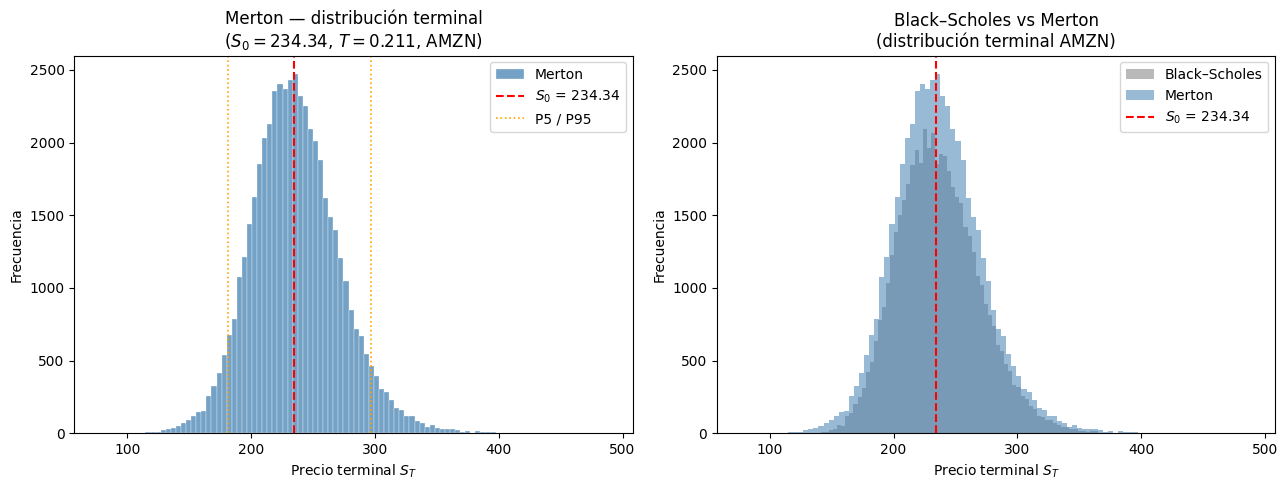


Estadísticas de $S_T$ bajo Merton (S0=234.34, T=0.211)
  Media          : 236.11
  Mediana        : 234.16
  Desv. estándar : 35.70
  Percentil  5%  : 181.67
  Percentil 95%  : 297.13
  Sesgo (skew)   : 0.4084
  Curtosis       : 0.9348


In [ ]:
# Parámetros de la fecha inicial del proyecto
S0_plot = float(df_bs.loc[0, "S"])        # 234.34
T_plot  = float(df_bs.loc[0, "T"])        # 0.211
r_plot  = float(df_bs.loc[0, "r_cont"])   # 0.0417
sig_bs  = float(df_bs.loc[0, "sigma"])    # 0.3046

# Distribución BS
rng_plot = np.random.default_rng(0)
z_bs = rng_plot.standard_normal(50_000)
ST_bs = S0_plot * np.exp(
    (r_plot - 0.5 * sig_bs**2) * T_plot + sig_bs * np.sqrt(T_plot) * z_bs
)

# Distribución Merton
ST_merton = simulate_merton_terminal(
    S0=S0_plot, T=T_plot, r=r_plot,
    sigma=merton_params["sigma"],
    lambda_j=merton_params["lambda_j"],
    mu_j=merton_params["mu_j"],
    sigma_j=merton_params["sigma_j"],
    n_paths=50_000, seed=1,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: solo Merton con percentiles
ax = axes[0]
ax.hist(ST_merton, bins=100, color="steelblue", alpha=0.75,
        edgecolor="white", linewidth=0.3, label="Merton")
ax.axvline(S0_plot,                              color="red",    linestyle="--", lw=1.5, label=f"$S_0$ = {S0_plot}")
ax.axvline(np.percentile(ST_merton,  5),         color="orange", linestyle=":",  lw=1.2, label="P5 / P95")
ax.axvline(np.percentile(ST_merton, 95),         color="orange", linestyle=":",  lw=1.2)
ax.set_xlabel("Precio terminal $S_T$")
ax.set_ylabel("Frecuencia")
ax.set_title(f"Merton — distribución terminal\n($S_0={S0_plot}$, $T={T_plot}$, AMZN)")
ax.legend()

# Panel derecho: BS vs Merton superpuestos
ax2 = axes[1]
ax2.hist(ST_bs,     bins=100, alpha=0.55, color="gray",      label="Black–Scholes")
ax2.hist(ST_merton, bins=100, alpha=0.55, color="steelblue", label="Merton")
ax2.axvline(S0_plot, color="red", linestyle="--", lw=1.5, label=f"$S_0$ = {S0_plot}")
ax2.set_xlabel("Precio terminal $S_T$")
ax2.set_ylabel("Frecuencia")
ax2.set_title("Black–Scholes vs Merton\n(distribución terminal AMZN)")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de $S_T$ bajo Merton (S0={S0_plot}, T={T_plot})")
print(f"  Media          : {ST_merton.mean():,.2f}")
print(f"  Mediana        : {np.median(ST_merton):,.2f}")
print(f"  Desv. estándar : {ST_merton.std():,.2f}")
print(f"  Percentil  5%  : {np.percentile(ST_merton,  5):,.2f}")
print(f"  Percentil 95%  : {np.percentile(ST_merton, 95):,.2f}")
print(f"  Sesgo (skew)   : {float(pd.Series(ST_merton).skew()):,.4f}")
print(f"  Curtosis       : {float(pd.Series(ST_merton).kurtosis()):,.4f}")